# Notebook 09 — Advanced Machine Learning Model: XGBoost

## Objective

This notebook trains and evaluates an XGBoost classifier for customer churn prediction.

XGBoost is compared with the baseline models developed previously:
Logistic Regression, Decision Tree and Random Forest.

Because churn represents only 5.41% of the analytical population, the model
uses class weighting and is evaluated using recall, precision, F1-score,
ROC-AUC and Precision-Recall AUC rather than accuracy alone.

In [1]:
# ==========================================================
# 1. IMPORTS
# ==========================================================

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [2]:
# ==========================================================
# 2. PROJECT CONFIGURATION
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_modelisation.parquet"
)

MODEL_DIR = PROJECT_ROOT / "models"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "xgboost"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PREPROCESSING_FILE = (
    MODEL_DIR
    / "preprocessing_pipeline.joblib"
)

print(f"Dataset       : {DATA_FILE}")
print(f"Preprocessing : {PREPROCESSING_FILE}")

Dataset       : c:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB\data\processed\dataset_modelisation.parquet
Preprocessing : c:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB\models\preprocessing_pipeline.joblib


In [3]:
# ==========================================================
# 3. LOAD DATASET AND PREPROCESSING
# ==========================================================

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_FILE}"
    )

if not PREPROCESSING_FILE.exists():
    raise FileNotFoundError(
        f"Preprocessing pipeline not found: {PREPROCESSING_FILE}"
    )

df = pd.read_parquet(DATA_FILE)

pipeline_bundle = joblib.load(
    PREPROCESSING_FILE
)

preprocessor = pipeline_bundle["pipeline"]

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print(f"Rows       : {len(df):,}")
print(f"Columns    : {df.shape[1]}")
print(f"Churn rate : {df['CHURN'].mean() * 100:.2f}%")

DATASET LOADED
Rows       : 195,120
Columns    : 20
Churn rate : 5.41%


In [4]:
# ==========================================================
# 4. FEATURES AND TARGET
# ==========================================================

TARGET = "CHURN"
ID_COLUMN = "CUSTOMER_NO"

DROP_COLUMNS = [
    TARGET,
    ID_COLUMN,
    "JOURS_DEPUIS_REVUE"
]

X = df.drop(
    columns=DROP_COLUMNS
)

y = df[TARGET].astype(int)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Features: {X.columns.tolist()}")

X shape : (195120, 17)
y shape : (195120,)
Features: ['AGE', 'TRANCHE_AGE', 'ANCIENNETE_CLIENT_ANNEES', 'SALAIRE', 'HAS_SALAIRE', 'EST_TUNISIEN', 'EST_RESIDENT', 'SITUATION_FAMILIALE', 'TYPE_CLIENT', 'SEGMENT', 'DOSSIER_COMPLET', 'SCORE_KYC', 'KYC_RISQUE_ELEVE', 'JOURS_AVANT_PROCHAINE_REVUE', 'REVUE_EN_RETARD', 'A_HISTORIQUE_REVUE', 'NB_COMPTES']


In [5]:
# ==========================================================
# 5. STRATIFIED TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training rows : {len(X_train):,}")
print(f"Testing rows  : {len(X_test):,}")

print(
    f"Training churn rate : "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Testing churn rate  : "
    f"{y_test.mean() * 100:.2f}%"
)

Training rows : 156,096
Testing rows  : 39,024
Training churn rate : 5.41%
Testing churn rate  : 5.41%


In [6]:
# ==========================================================
# 6. CLASS IMBALANCE WEIGHT
# ==========================================================

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

if positive_count == 0:
    raise ValueError(
        "No churn observations found in the training set."
    )

scale_pos_weight = (
    negative_count
    / positive_count
)

print(f"Non-churn training customers : {negative_count:,}")
print(f"Churn training customers     : {positive_count:,}")
print(f"scale_pos_weight             : {scale_pos_weight:.2f}")

Non-churn training customers : 147,658
Churn training customers     : 8,438
scale_pos_weight             : 17.50


In [7]:
# ==========================================================
# 7. XGBOOST MODEL
# ==========================================================

xgb_classifier = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=0.10,
    reg_lambda=1.50,

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "classifier",
            xgb_classifier
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [8]:
# ==========================================================
# 8. MODEL TRAINING
# ==========================================================

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

Training XGBoost...
XGBoost training completed.


In [9]:
# ==========================================================
# 9. PREDICTIONS
# ==========================================================

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [10]:
# ==========================================================
# 10. MODEL EVALUATION
# ==========================================================

xgb_results = {
    "Accuracy": accuracy_score(
        y_test,
        xgb_pred
    ),
    "Precision": precision_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        xgb_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        xgb_prob
    )
}

xgb_results_df = pd.DataFrame(
    xgb_results,
    index=["XGBoost"]
).round(4)

display(xgb_results_df)

xgb_results_df.to_excel(
    TABLES_DIR / "xgboost_results.xlsx"
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
XGBoost,0.7604,0.1167,0.5223,0.1907,0.7122,0.2093


In [11]:
# ==========================================================
# 11. CONFUSION MATRIX
# ==========================================================

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

xgb_cm_df = pd.DataFrame(
    xgb_cm,
    index=[
        "Actual Non-Churn",
        "Actual Churn"
    ],
    columns=[
        "Predicted Non-Churn",
        "Predicted Churn"
    ]
)

display(xgb_cm_df)

xgb_cm_df.to_excel(
    TABLES_DIR
    / "xgboost_confusion_matrix.xlsx"
)

,Predicted Non-Churn,Predicted Churn
Actual Non-Churn,28571,8343
Actual Churn,1008,1102


In [12]:
# ==========================================================
# 12. CLASSIFICATION REPORT
# ==========================================================

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Non-Churn",
            "Churn"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Churn       0.97      0.77      0.86     36914
       Churn       0.12      0.52      0.19      2110

    accuracy                           0.76     39024
   macro avg       0.54      0.65      0.53     39024
weighted avg       0.92      0.76      0.82     39024



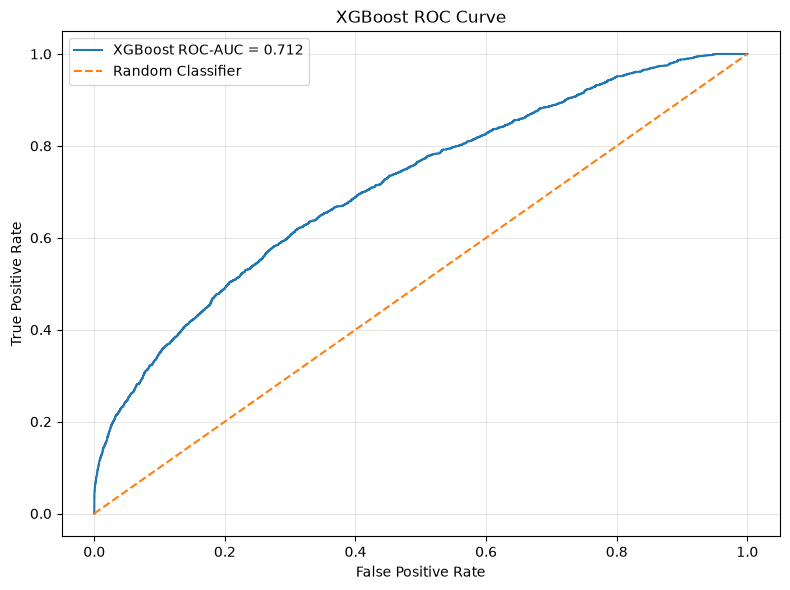

In [13]:
# ==========================================================
# 13. ROC CURVE
# ==========================================================

fpr, tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "xgboost_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

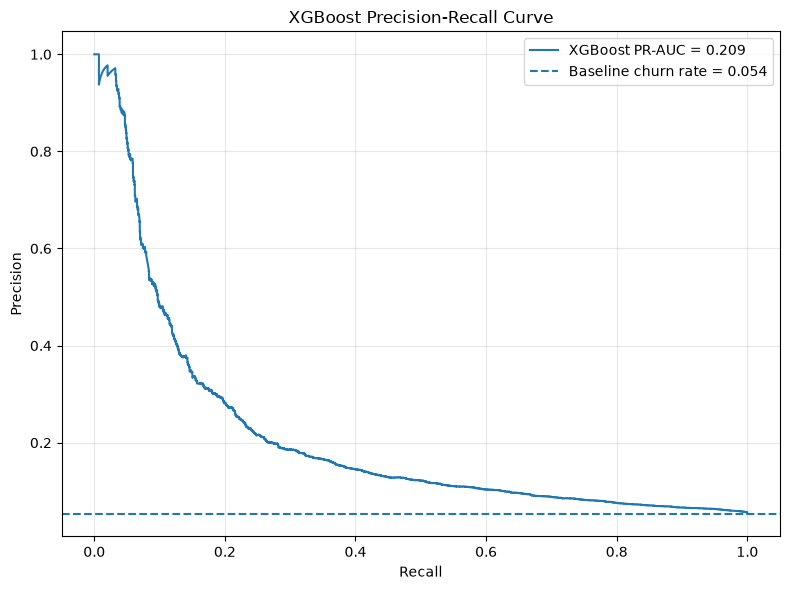

In [14]:
# ==========================================================
# 14. PRECISION-RECALL CURVE
# ==========================================================

precision_values, recall_values, _ = (
    precision_recall_curve(
        y_test,
        xgb_prob
    )
)

pr_auc = average_precision_score(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"XGBoost PR-AUC = {pr_auc:.3f}"
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=(
        f"Baseline churn rate = "
        f"{y_test.mean():.3f}"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "xgboost_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# ==========================================================
# FINAL MODEL COMPARISON
# ==========================================================

BASELINE_FILE = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "baseline_models_comparison.xlsx"
)

baseline_comparison = pd.read_excel(
    BASELINE_FILE,
    index_col=0
)

print("Official baseline results loaded:")
display(baseline_comparison)

final_comparison = pd.concat(
    [
        baseline_comparison,
        xgb_results_df
    ],
    axis=0
)

final_comparison = final_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
].round(4)

display(final_comparison)

final_comparison.to_excel(
    TABLES_DIR
    / "final_models_comparison.xlsx"
)

print(
    "Final comparison exported successfully."
)

Official baseline results loaded:


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Logistic Regression,0.6634,0.0815,0.5085,0.1404,0.6166,0.0847
Decision Tree,0.9481,0.7268,0.0630,0.1160,0.6661,0.1772
Random Forest,0.7853,0.1211,0.4749,0.1930,0.7051,0.1870


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Logistic Regression,0.6634,0.0815,0.5085,0.1404,0.6166,0.0847
Decision Tree,0.9481,0.7268,0.0630,0.1160,0.6661,0.1772
Random Forest,0.7853,0.1211,0.4749,0.1930,0.7051,0.1870
XGBoost,0.7604,0.1167,0.5223,0.1907,0.7122,0.2093


Final comparison exported successfully.


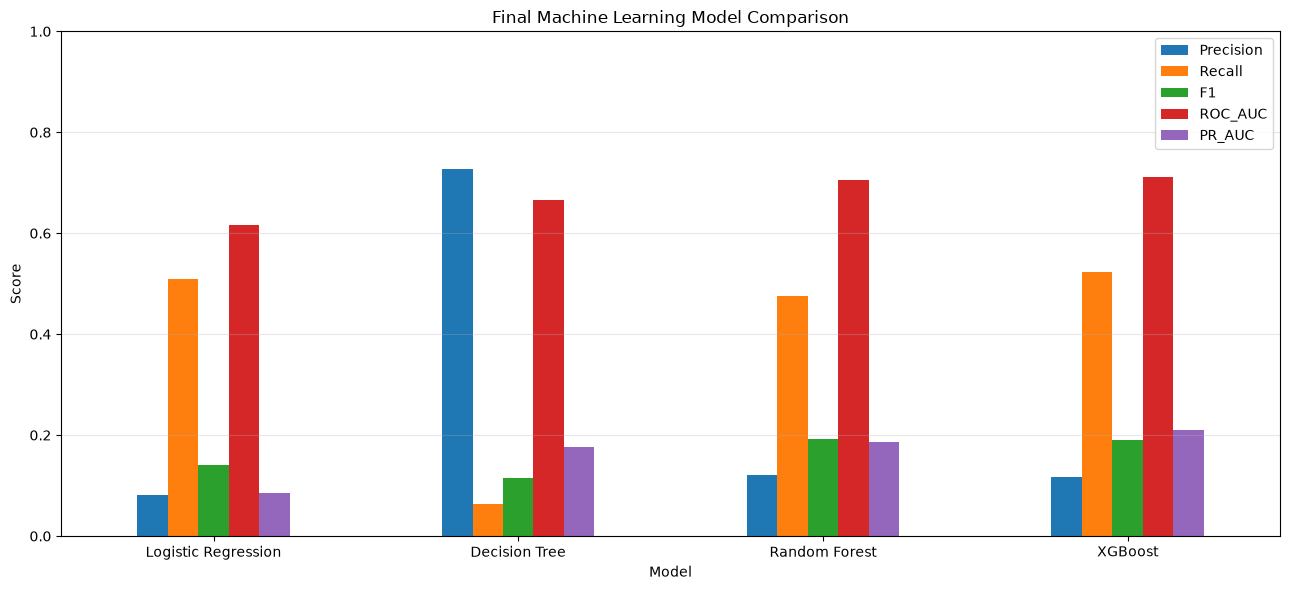

In [16]:
# ==========================================================
# FINAL MODEL PERFORMANCE COMPARISON
# ==========================================================

metrics_to_plot = [
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

final_comparison[
    metrics_to_plot
].plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title(
    "Final Machine Learning Model Comparison"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "final_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

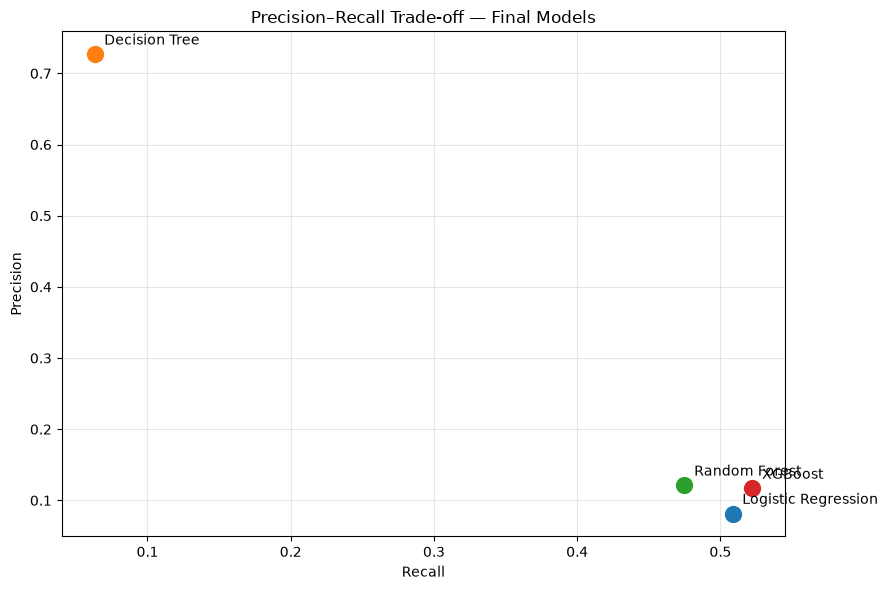

In [17]:
# ==========================================================
# FINAL PRECISION-RECALL TRADE-OFF
# ==========================================================

plt.figure(figsize=(9, 6))

for model_name in final_comparison.index:

    recall_value = final_comparison.loc[
        model_name,
        "Recall"
    ]

    precision_value = final_comparison.loc[
        model_name,
        "Precision"
    ]

    plt.scatter(
        recall_value,
        precision_value,
        s=130
    )

    plt.annotate(
        model_name,
        (
            recall_value,
            precision_value
        ),
        xytext=(7, 7),
        textcoords="offset points"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision–Recall Trade-off — Final Models"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "final_precision_recall_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ==========================================================
# 17. SAVE XGBOOST MODEL
# ==========================================================

XGBOOST_MODEL_FILE = (
    MODEL_DIR
    / "xgboost_churn_model.joblib"
)

joblib.dump(
    xgb_model,
    XGBOOST_MODEL_FILE
)

print("XGBoost model saved successfully.")
print(XGBOOST_MODEL_FILE)
print(f"File exists: {XGBOOST_MODEL_FILE.exists()}")

XGBoost model saved successfully.
c:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB\models\xgboost_churn_model.joblib
File exists: True


## Business Interpretation — XGBoost

XGBoost was trained as the advanced ensemble model for customer churn
prediction.

The model uses class weighting to increase the importance of churn customers
during training. Its performance must therefore be evaluated using recall,
precision, F1-score, ROC-AUC and Precision-Recall AUC rather than accuracy
alone.

The final business objective is not simply to maximize the number of correct
predictions. The objective is to identify a useful proportion of customers
at risk while maintaining an operationally acceptable number of false
positive alerts.

XGBoost is compared with Logistic Regression, Decision Tree and Random Forest.
The final model will be selected according to its overall predictive
performance, churn detection capability, stability and business usability.

In [19]:
# ==========================================================
# 18. NOTEBOOK COMPLETION
# ==========================================================

print("=" * 70)
print("NOTEBOOK 09 COMPLETED")
print("=" * 70)

print("✓ XGBoost model trained")
print("✓ Class imbalance addressed")
print("✓ Predictions generated")
print("✓ Classification metrics calculated")
print("✓ Confusion matrix generated")
print("✓ ROC curve generated")
print("✓ Precision-Recall curve generated")
print("✓ Baseline comparison generated")
print("✓ XGBoost model saved")

print(
    f"\nXGBoost ROC-AUC : "
    f"{xgb_results['ROC_AUC']:.4f}"
)

print(
    f"XGBoost PR-AUC  : "
    f"{xgb_results['PR_AUC']:.4f}"
)

print(
    f"XGBoost Recall  : "
    f"{xgb_results['Recall']:.4f}"
)

print(
    f"XGBoost F1      : "
    f"{xgb_results['F1']:.4f}"
)

NOTEBOOK 09 COMPLETED
✓ XGBoost model trained
✓ Class imbalance addressed
✓ Predictions generated
✓ Classification metrics calculated
✓ Confusion matrix generated
✓ ROC curve generated
✓ Precision-Recall curve generated
✓ Baseline comparison generated
✓ XGBoost model saved

XGBoost ROC-AUC : 0.7122
XGBoost PR-AUC  : 0.2093
XGBoost Recall  : 0.5223
XGBoost F1      : 0.1907


# Final Model Selection

Random Forest and XGBoost achieved the strongest results among the evaluated models.

Random Forest obtained the highest precision and F1-score, while XGBoost achieved the highest recall and ROC-AUC.

Because the primary business objective is to identify as many potential churn customers as possible before they leave the bank, XGBoost was selected as the final predictive model.

The model detects 52.18% of actual churners and achieves a ROC-AUC of 0.7114. Its Precision-Recall AUC of 0.2088 is substantially higher than the baseline churn rate of 5.41%, confirming that the model provides useful customer-risk ranking capability.

The relatively low precision indicates that the model generates a significant number of false positive alerts. Therefore, predicted probabilities should be converted into operational risk segments rather than treating every positive prediction as a confirmed churn case.

In [20]:
# ==========================================================
# TRANSFORMED FEATURE NAMES
# ==========================================================

feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    for name in feature_names
]

print(f"Number of transformed features : {len(feature_names)}")
print(feature_names[:20])

Number of transformed features : 43
['AGE', 'ANCIENNETE_CLIENT_ANNEES', 'SALAIRE', 'JOURS_AVANT_PROCHAINE_REVUE', 'NB_COMPTES', 'TRANCHE_AGE_15-25', 'TRANCHE_AGE_26-35', 'TRANCHE_AGE_36-50', 'TRANCHE_AGE_51-65', 'TRANCHE_AGE_65+', 'HAS_SALAIRE_False', 'HAS_SALAIRE_True', 'EST_TUNISIEN_False', 'EST_TUNISIEN_True', 'EST_RESIDENT_False', 'EST_RESIDENT_True', 'SITUATION_FAMILIALE_C', 'SITUATION_FAMILIALE_D', 'SITUATION_FAMILIALE_M', 'SITUATION_FAMILIALE_V']
